In [ ]:
!pip install spacy torch scikit-learn pandas numpy matplotlib wordcloud
!python -m spacy download en_core_web_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 16.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import pandas as pd
import numpy as np
import spacy
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from wordcloud import WordCloud


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load spaCy model with pretrained word vectors
nlp = spacy.load("en_core_web_md")
df = pd.read_csv("/content/drive/MyDrive/fake_reviews_dataset.csv")

# Keep only relevant columns
df = df[['category', 'label', 'text_']]
df.dropna(inplace=True)

print(df.head())

             category label                                              text_
0  Home_and_Kitchen_5    CG  Love this!  Well made, sturdy, and very comfor...
1  Home_and_Kitchen_5    CG  love it, a great upgrade from the original.  I...
2  Home_and_Kitchen_5    CG  This pillow saved my back. I love the look and...
3  Home_and_Kitchen_5    CG  Missing information on how to use it, but it i...
4  Home_and_Kitchen_5    CG  Very nice set. Good quality. We have had the s...


In [ ]:
def spacy_preprocess(text):

    doc = nlp(text.lower())
    tokens = [
        token.lemma_
        for token in doc
        if not token.is_stop and not token.is_punct and token.is_alpha
    ]
    return " ".join(tokens)
# Apply preprocessing
df['clean_text'] = df['text_'].apply(spacy_preprocess)


In [ ]:
tfidf = TfidfVectorizer(
    max_features=5000,    # limit vocabulary size
    ngram_range=(1, 2)    # unigrams + bigrams
)

X_tfidf = tfidf.fit_transform(df['clean_text']).toarray()


Product Category: Classification

In [ ]:
category_encoder = LabelEncoder()
y_category = category_encoder.fit_transform(df['category'])

num_classes = len(category_encoder.classes_)
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y_category, test_size=0.2, random_state=42, stratify=y_category)



In [ ]:
class ReviewDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
train_loader = DataLoader(
    ReviewDataset(X_train, y_train),
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    ReviewDataset(X_test, y_test),
    batch_size=32
)


In [ ]:
class CategoryClassifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, num_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        return self.fc3(x)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CategoryClassifier(
    input_dim=X_tfidf.shape[1],
    num_classes=num_classes
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss:.4f}")


Epoch [1/10], Loss: 904.4162
Epoch [2/10], Loss: 504.4652
Epoch [3/10], Loss: 378.3915
Epoch [4/10], Loss: 279.6558
Epoch [5/10], Loss: 192.8711
Epoch [6/10], Loss: 122.0063
Epoch [7/10], Loss: 75.4950
Epoch [8/10], Loss: 49.6522
Epoch [9/10], Loss: 33.4996
Epoch [10/10], Loss: 26.8033


In [ ]:
model.eval()
y_preds, y_true = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1)

        y_preds.extend(preds.cpu().numpy())
        y_true.extend(y_batch.numpy())

print("Accuracy:", accuracy_score(y_true, y_preds))
print(classification_report(
    y_true,
    y_preds,
    target_names=category_encoder.classes_
))


Accuracy: 0.749721775689378
                              precision    recall  f1-score   support

                     Books_5       0.74      0.73      0.74       874
Clothing_Shoes_and_Jewelry_5       0.78      0.77      0.78       770
               Electronics_5       0.74      0.80      0.77       798
          Home_and_Kitchen_5       0.70      0.66      0.68       811
              Kindle_Store_5       0.79      0.76      0.77       946
             Movies_and_TV_5       0.90      0.87      0.88       717
              Pet_Supplies_5       0.90      0.81      0.85       851
       Sports_and_Outdoors_5       0.55      0.65      0.59       789
Tools_and_Home_Improvement_5       0.67      0.68      0.68       772
            Toys_and_Games_5       0.80      0.78      0.79       759

                    accuracy                           0.75      8087
                   macro avg       0.76      0.75      0.75      8087
                weighted avg       0.76      0.75      0.75 

Task 2: Fake Review Detection


In [ ]:
df['fake_label'] = df['label'].apply(lambda x: 0 if x == 'CG' else 1)


In [ ]:
class FakeReviewClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.sigmoid(self.fc3(x))

In [ ]:
EPOCHS = 10
BATCH_SIZE = 32

categories = df['category'].unique()

for category in categories:
    print("\n" + "="*60)
    print(f"Category: {category}")
    print("="*60)

    # Filter data for one category
    cat_df = df[df['category'] == category]

    # Skip very small categories
    if len(cat_df) < 50:
        print("Skipping category (insufficient samples)")
        continue

    X_cat = X_tfidf[cat_df.index]
    y_cat = cat_df['fake_label'].values

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_cat,
        y_cat,
        test_size=0.2,
        random_state=42,
        stratify=y_cat
    )

    train_loader = DataLoader(
        ReviewDataset(X_train, y_train),
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    test_loader = DataLoader(
        ReviewDataset(X_test, y_test),
        batch_size=BATCH_SIZE
    )

    # Model, loss, optimizer
    model = FakeReviewClassifier(X_cat.shape[1]).to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Training
    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            y_batch = y_batch.float()  # Convert target labels to float

            optimizer.zero_grad()
            outputs = model(X_batch).squeeze()
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {total_loss:.4f}")

    # Evaluation
    model.eval()
    y_preds, y_true = [], []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch).squeeze()
            preds = (outputs > 0.5).int().cpu().numpy()

            y_preds.extend(preds)
            y_true.extend(y_batch.numpy())

    print("\nAccuracy:", accuracy_score(y_true, y_preds))
    print(classification_report(
        y_true,
        y_preds,
        target_names=["Genuine", "Fake"]
    ))



Category: Home_and_Kitchen_5
Epoch [1/10], Loss: 56.1409
Epoch [2/10], Loss: 23.3240
Epoch [3/10], Loss: 13.1964
Epoch [4/10], Loss: 8.0364
Epoch [5/10], Loss: 4.8680
Epoch [6/10], Loss: 2.9917
Epoch [7/10], Loss: 1.9784
Epoch [8/10], Loss: 1.0957
Epoch [9/10], Loss: 0.5921
Epoch [10/10], Loss: 0.3959

Accuracy: 0.8325123152709359
              precision    recall  f1-score   support

     Genuine       0.83      0.83      0.83       406
        Fake       0.83      0.83      0.83       406

    accuracy                           0.83       812
   macro avg       0.83      0.83      0.83       812
weighted avg       0.83      0.83      0.83       812


Category: Sports_and_Outdoors_5
Epoch [1/10], Loss: 54.7152
Epoch [2/10], Loss: 20.8831
Epoch [3/10], Loss: 10.8826
Epoch [4/10], Loss: 6.1524
Epoch [5/10], Loss: 3.4170
Epoch [6/10], Loss: 1.9105
Epoch [7/10], Loss: 1.1229
Epoch [8/10], Loss: 0.7480
Epoch [9/10], Loss: 0.4406
Epoch [10/10], Loss: 0.3054

Accuracy: 0.8430379746835444
  

Task 3: Word cloud

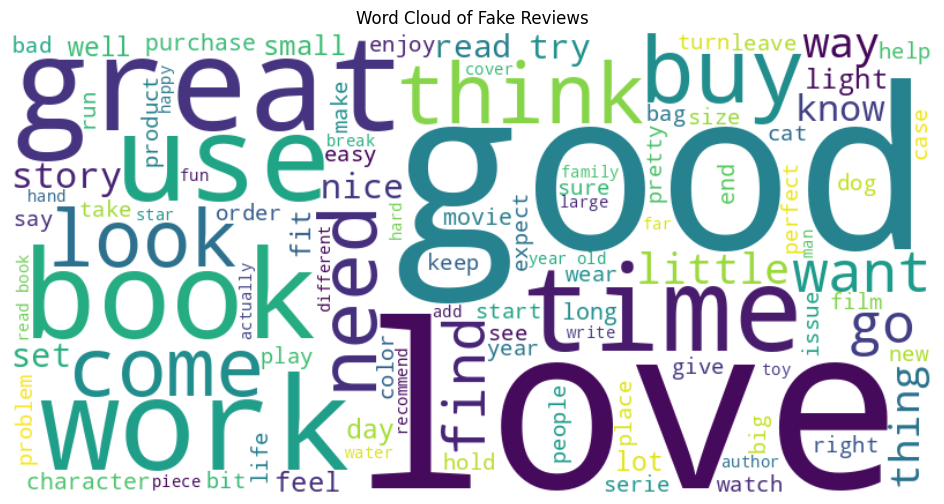

In [ ]:
fake_text = " ".join(df[df['fake_label'] == 1]['clean_text'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=100
).generate(fake_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Fake Reviews")
plt.show()
